# Stock Market Price Prediction
**Model**: Bidirectional LSTM with Technical Indicators  
**Dataset**: [Price/Volume Data for All US Stocks & ETFs](https://www.kaggle.com/datasets/borismarjanovic/price-volume-data-for-all-us-stocks-etfs) (Kaggle)  
**Goal**: Predict next-day closing price using 60-day historical sequences + 10 technical indicators

**Pipeline**
1. Download dataset via Kaggle API
2. EDA — price history, returns, correlation
3. Feature Engineering — 10 technical indicators (SMA, EMA, MACD, RSI, Bollinger Bands, Momentum, Volatility)
4. Train/Val/Test split (80/10/10)
5. Model Comparison — Moving Average baseline, vanilla LSTM, Bidirectional LSTM
6. Evaluation — RMSE, MAE, MAPE, Directional Accuracy
7. 30-day Future Forecast

## 0 · Setup

In [1]:
import warnings, json, os, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, mixed_precision

warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '1'
sns.set_theme(style='darkgrid')
plt.rcParams['figure.dpi'] = 120

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

os.makedirs('models', exist_ok=True)
os.makedirs('plots',  exist_ok=True)

# ── GPU Configuration ─────────────────────────────────────────────────────────
print("=" * 55)
print("  GPU / Hardware Configuration")
print("=" * 55)

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"   GPU detected: {len(gpus)} device(s)")
    for gpu in gpus:
        print(f"     → {gpu.name}")
    # Enable memory growth to avoid allocating all GPU memory at once
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    # Enable mixed precision (float16 compute + float32 weights)
    # Gives ~2-3× speedup on NVIDIA T4/P100/A100 with minimal accuracy loss
    mixed_precision.set_global_policy('mixed_float16')
    print(f"   Mixed precision enabled: {mixed_precision.global_policy().name}")
    # Use MirroredStrategy for multi-GPU (works on single GPU too)
    strategy = tf.distribute.MirroredStrategy()
    print(f"   Strategy: MirroredStrategy ({strategy.num_replicas_in_sync} replica(s))")
    BATCH_SIZE = 64   # Larger batch takes advantage of GPU parallelism
    USE_GPU = True
else:
    print("   No GPU found — running on CPU")
    print("     Tip: Enable GPU in Kaggle → Settings → Accelerator → GPU T4 x2")
    strategy = tf.distribute.get_strategy()   # Default (CPU) strategy
    BATCH_SIZE = 32
    USE_GPU = False

cpus = tf.config.list_physical_devices('CPU')
print(f"  ℹ️  CPU cores: {os.cpu_count()}")
print(f"  ℹ️  TensorFlow: {tf.__version__}")
print(f"  ℹ️  Batch size: {BATCH_SIZE}")
print("=" * 55)


  GPU / Hardware Configuration
   GPU detected: 1 device(s)
     → /physical_device:GPU:0
   Mixed precision enabled: mixed_float16
   Strategy: MirroredStrategy (1 replica(s))
  ℹ️  CPU cores: 2
  ℹ️  TensorFlow: 2.20.0
  ℹ️  Batch size: 64


In [2]:
# ── Verify GPU memory & compute capability ────────────────────────────────────
if USE_GPU:
    from tensorflow.python.client import device_lib
    local_devices = device_lib.list_local_devices()
    for d in local_devices:
        if d.device_type == 'GPU':
            props = d.physical_device_desc
            # Extract key info
            for part in props.split(','):
                part = part.strip()
                if any(k in part for k in ['name', 'compute capability', 'memory']):
                    print(f"  {part}")
    print()
    # Quick GPU benchmark
    import time
    print("Running GPU benchmark (matrix multiply)...")
    with tf.device('/GPU:0'):
        a = tf.random.normal([4096, 4096])
        t0 = time.time()
        for _ in range(10):
            _ = tf.matmul(a, a)
        elapsed = time.time() - t0
    print(f"  4096×4096 matmul × 10 iterations: {elapsed:.2f}s")
    print(f"  → {'Excellent' if elapsed < 1 else 'Good' if elapsed < 3 else 'OK'} GPU performance")
else:
    print("GPU not available — skipping benchmark")


  name: Tesla T4
  compute capability: 7.5

Running GPU benchmark (matrix multiply)...
  4096×4096 matmul × 10 iterations: 0.32s
  → Excellent GPU performance


## 1 · Download Dataset (Kaggle)

In [3]:
!pip install kagglehub

In [4]:
import kagglehub
path = kagglehub.dataset_download('borismarjanovic/price-volume-data-for-all-us-stocks-etfs')
print('Dataset path:', path)

import glob
stock_files = glob.glob(f'{path}/Stocks/*.txt')
etf_files   = glob.glob(f'{path}/ETFs/*.txt')
print(f'Stocks: {len(stock_files)}  ETFs: {len(etf_files)}')

100%|██████████| 492M/492M [00:07<00:00, 72.7MB/s]

Extracting files...


Dataset path: /root/.cache/kagglehub/datasets/borismarjanovic/price-volume-data-for-all-us-stocks-etfs/versions/3
Stocks: 7195  ETFs: 1344


In [5]:
def load_stock(path, ticker):
    """Load a single stock CSV file."""
    fname = f'{path}/Stocks/{ticker.lower()}.us.txt'
    df = pd.read_csv(fname, parse_dates=['Date'], index_col='Date')
    df.columns = [c.strip() for c in df.columns]
    df = df.sort_index()
    df = df[df['Volume'] > 0]  # remove non-trading days
    return df

TICKERS = ['aapl', 'msft', 'googl', 'amzn', 'tsla']
dfs = {}
for t in TICKERS:
    try:
        df = load_stock(path, t)
        dfs[t.upper()] = df
        print(f'{t.upper():6s}: {len(df):,} rows  |  {df.index[0].date()} → {df.index[-1].date()}')
    except FileNotFoundError:
        print(f'{t.upper()} not found')

AAPL  : 8,363 rows  |  1984-09-07 → 2017-11-10
MSFT  : 7,982 rows  |  1986-03-13 → 2017-11-10
GOOGL : 3,332 rows  |  2004-08-19 → 2017-11-10
AMZN  : 5,152 rows  |  1997-05-16 → 2017-11-10
TSLA  : 1,857 rows  |  2010-06-29 → 2017-11-10


## 2 · Exploratory Data Analysis

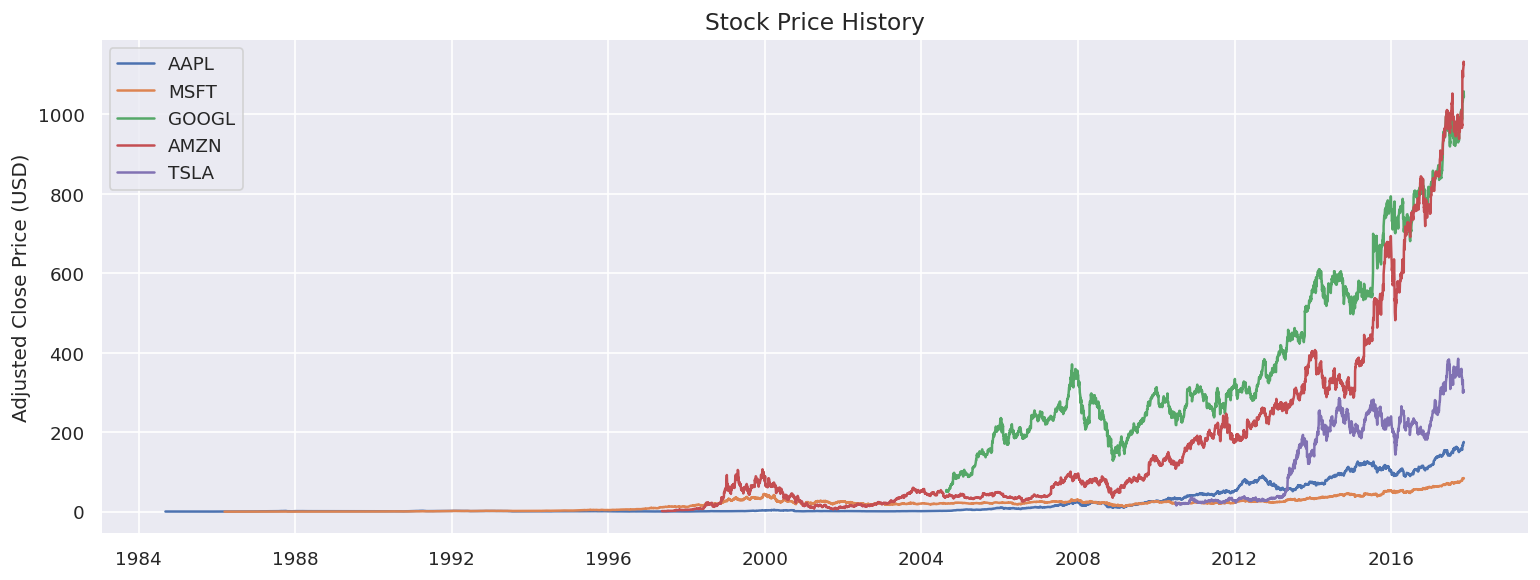

In [6]:
fig, ax = plt.subplots(figsize=(13, 5))
for ticker, df in dfs.items():
    ax.plot(df.index, df['Close'], label=ticker, linewidth=1.5)
ax.set_title('Stock Price History', fontsize=14)
ax.set_ylabel('Adjusted Close Price (USD)')
ax.legend()
plt.tight_layout()
plt.savefig('plots/price_history.png', bbox_inches='tight')
plt.show()

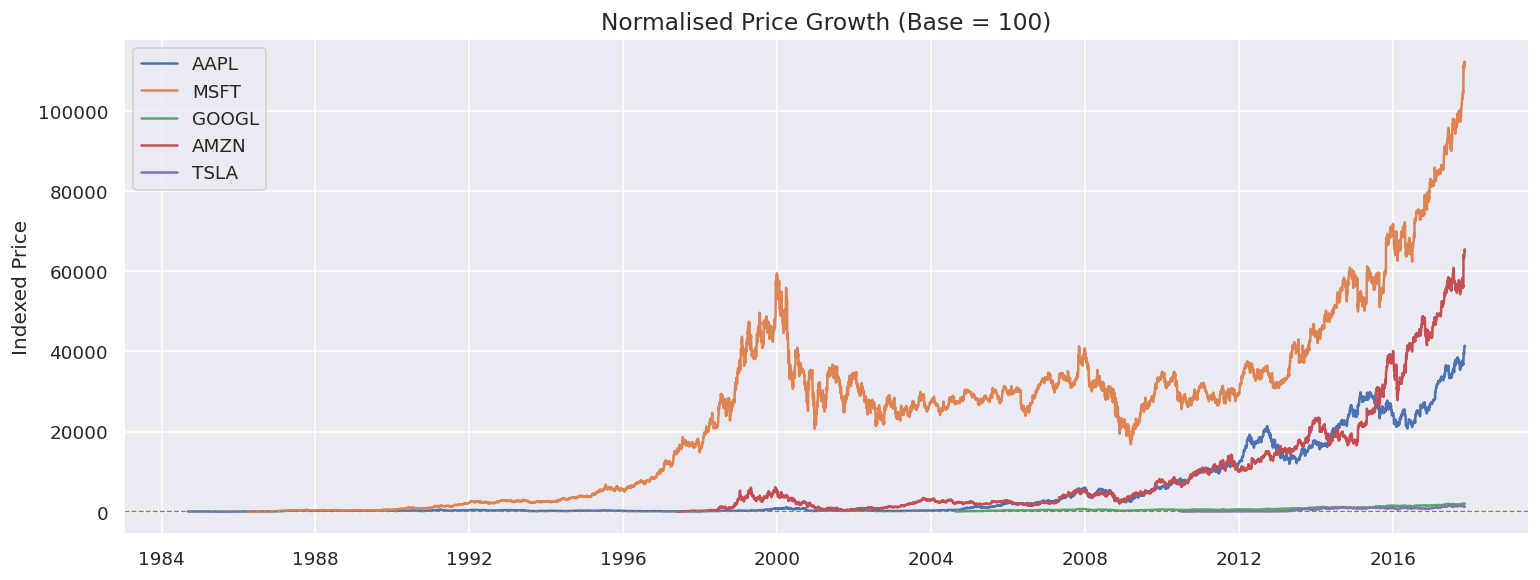

In [7]:
# Normalised growth (Base = 100)
fig, ax = plt.subplots(figsize=(13, 5))
for ticker, df in dfs.items():
    norm = df['Close'] / df['Close'].iloc[0] * 100
    ax.plot(df.index, norm, label=ticker, linewidth=1.5)
ax.axhline(100, color='gray', linestyle='--', linewidth=0.8)
ax.set_title('Normalised Price Growth (Base = 100)', fontsize=14)
ax.set_ylabel('Indexed Price')
ax.legend()
plt.tight_layout()
plt.savefig('plots/normalised_returns.png', bbox_inches='tight')
plt.show()

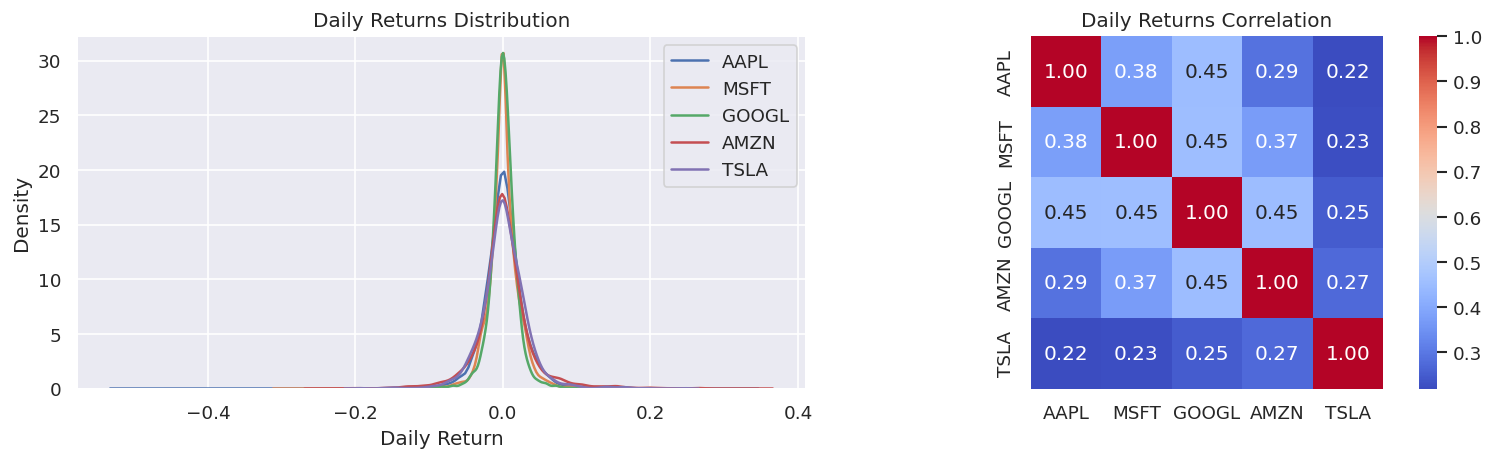

In [8]:
# Daily returns distribution
returns = pd.DataFrame({t: dfs[t]['Close'].pct_change().dropna() for t in dfs})

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ticker in returns.columns:
    sns.kdeplot(returns[ticker], label=ticker, ax=axes[0])
axes[0].set_title('Daily Returns Distribution', fontsize=12)
axes[0].set_xlabel('Daily Return')
axes[0].legend()

sns.heatmap(returns.corr(), annot=True, fmt='.2f', cmap='coolwarm',
            square=True, ax=axes[1])
axes[1].set_title('Daily Returns Correlation', fontsize=12)
plt.tight_layout()
plt.savefig('plots/correlation_heatmap.png', bbox_inches='tight')
plt.show()

## 3 · Feature Engineering — Technical Indicators

In [9]:
def add_indicators(df):
    d = df.copy()
    # Moving averages
    d['SMA_20'] = d['Close'].rolling(20).mean()
    d['SMA_50'] = d['Close'].rolling(50).mean()
    d['EMA_12'] = d['Close'].ewm(span=12, adjust=False).mean()
    d['EMA_26'] = d['Close'].ewm(span=26, adjust=False).mean()
    # MACD
    d['MACD']   = d['EMA_12'] - d['EMA_26']
    d['Signal'] = d['MACD'].ewm(span=9, adjust=False).mean()
    d['MACD_Hist'] = d['MACD'] - d['Signal']
    # RSI (14-period)
    delta = d['Close'].diff()
    gain  = delta.clip(lower=0).rolling(14).mean()
    loss  = (-delta.clip(upper=0)).rolling(14).mean()
    d['RSI'] = 100 - (100 / (1 + gain / (loss + 1e-9)))
    # Bollinger Bands
    d['BB_Mid']   = d['Close'].rolling(20).mean()
    d['BB_Std']   = d['Close'].rolling(20).std()
    d['BB_Upper'] = d['BB_Mid'] + 2 * d['BB_Std']
    d['BB_Lower'] = d['BB_Mid'] - 2 * d['BB_Std']
    d['BB_Width'] = (d['BB_Upper'] - d['BB_Lower']) / (d['BB_Mid'] + 1e-9)
    # Return & volatility
    d['Return']     = d['Close'].pct_change()
    d['Volatility'] = d['Return'].rolling(20).std()
    # Momentum
    d['Momentum_5']  = d['Close'] / d['Close'].shift(5)  - 1
    d['Momentum_20'] = d['Close'] / d['Close'].shift(20) - 1
    # Volume ratio
    d['Vol_Ratio'] = d['Volume'] / (d['Volume'].rolling(20).mean() + 1)
    return d.dropna()

TICKER = 'AAPL'   # ← change to any ticker in dfs
df = add_indicators(dfs[TICKER])
print(f'After feature engineering: {df.shape}')
df.head()

After feature engineering: (8314, 24)


,Open,High,Low,Close,Volume,OpenInt,SMA_20,SMA_50,EMA_12,EMA_26,...,BB_Mid,BB_Std,BB_Upper,BB_Lower,BB_Width,Return,Volatility,Momentum_5,Momentum_20,Vol_Ratio
Date,,,,,,,,,,,,,,,,,,,,,
1984-11-15,0.37906,0.38289,0.37906,0.37906,29729373,0,0.396991,0.404880,0.388358,0.394645,...,0.396991,0.013964,0.424918,0.369063,0.140698,0.000000,0.026901,-0.038968,-0.072137,0.783000
1984-11-16,0.37906,0.38419,0.36883,0.37138,46227662,0,0.395133,0.403830,0.385746,0.392922,...,0.395133,0.014794,0.424722,0.365544,0.149765,-0.020261,0.027146,0.000000,-0.090936,1.293718
1984-11-19,0.37138,0.37394,0.34962,0.34962,64974836,0,0.392317,0.402396,0.380188,0.389714,...,0.392317,0.017704,0.427725,0.356910,0.180502,-0.058592,0.029734,-0.089982,-0.138718,1.738178
1984-11-20,0.36112,0.36241,0.36112,0.36112,73414508,0,0.389628,0.401038,0.377255,0.387596,...,0.389628,0.018170,0.425969,0.353287,0.186541,0.032893,0.030380,-0.037578,-0.129643,1.909249
1984-11-21,0.36883,0.37138,0.36883,0.36883,49844653,0,0.387132,0.400091,0.375958,0.386206,...,0.387132,0.017371,0.421875,0.352390,0.179488,0.021350,0.030827,-0.026988,-0.119191,1.290797


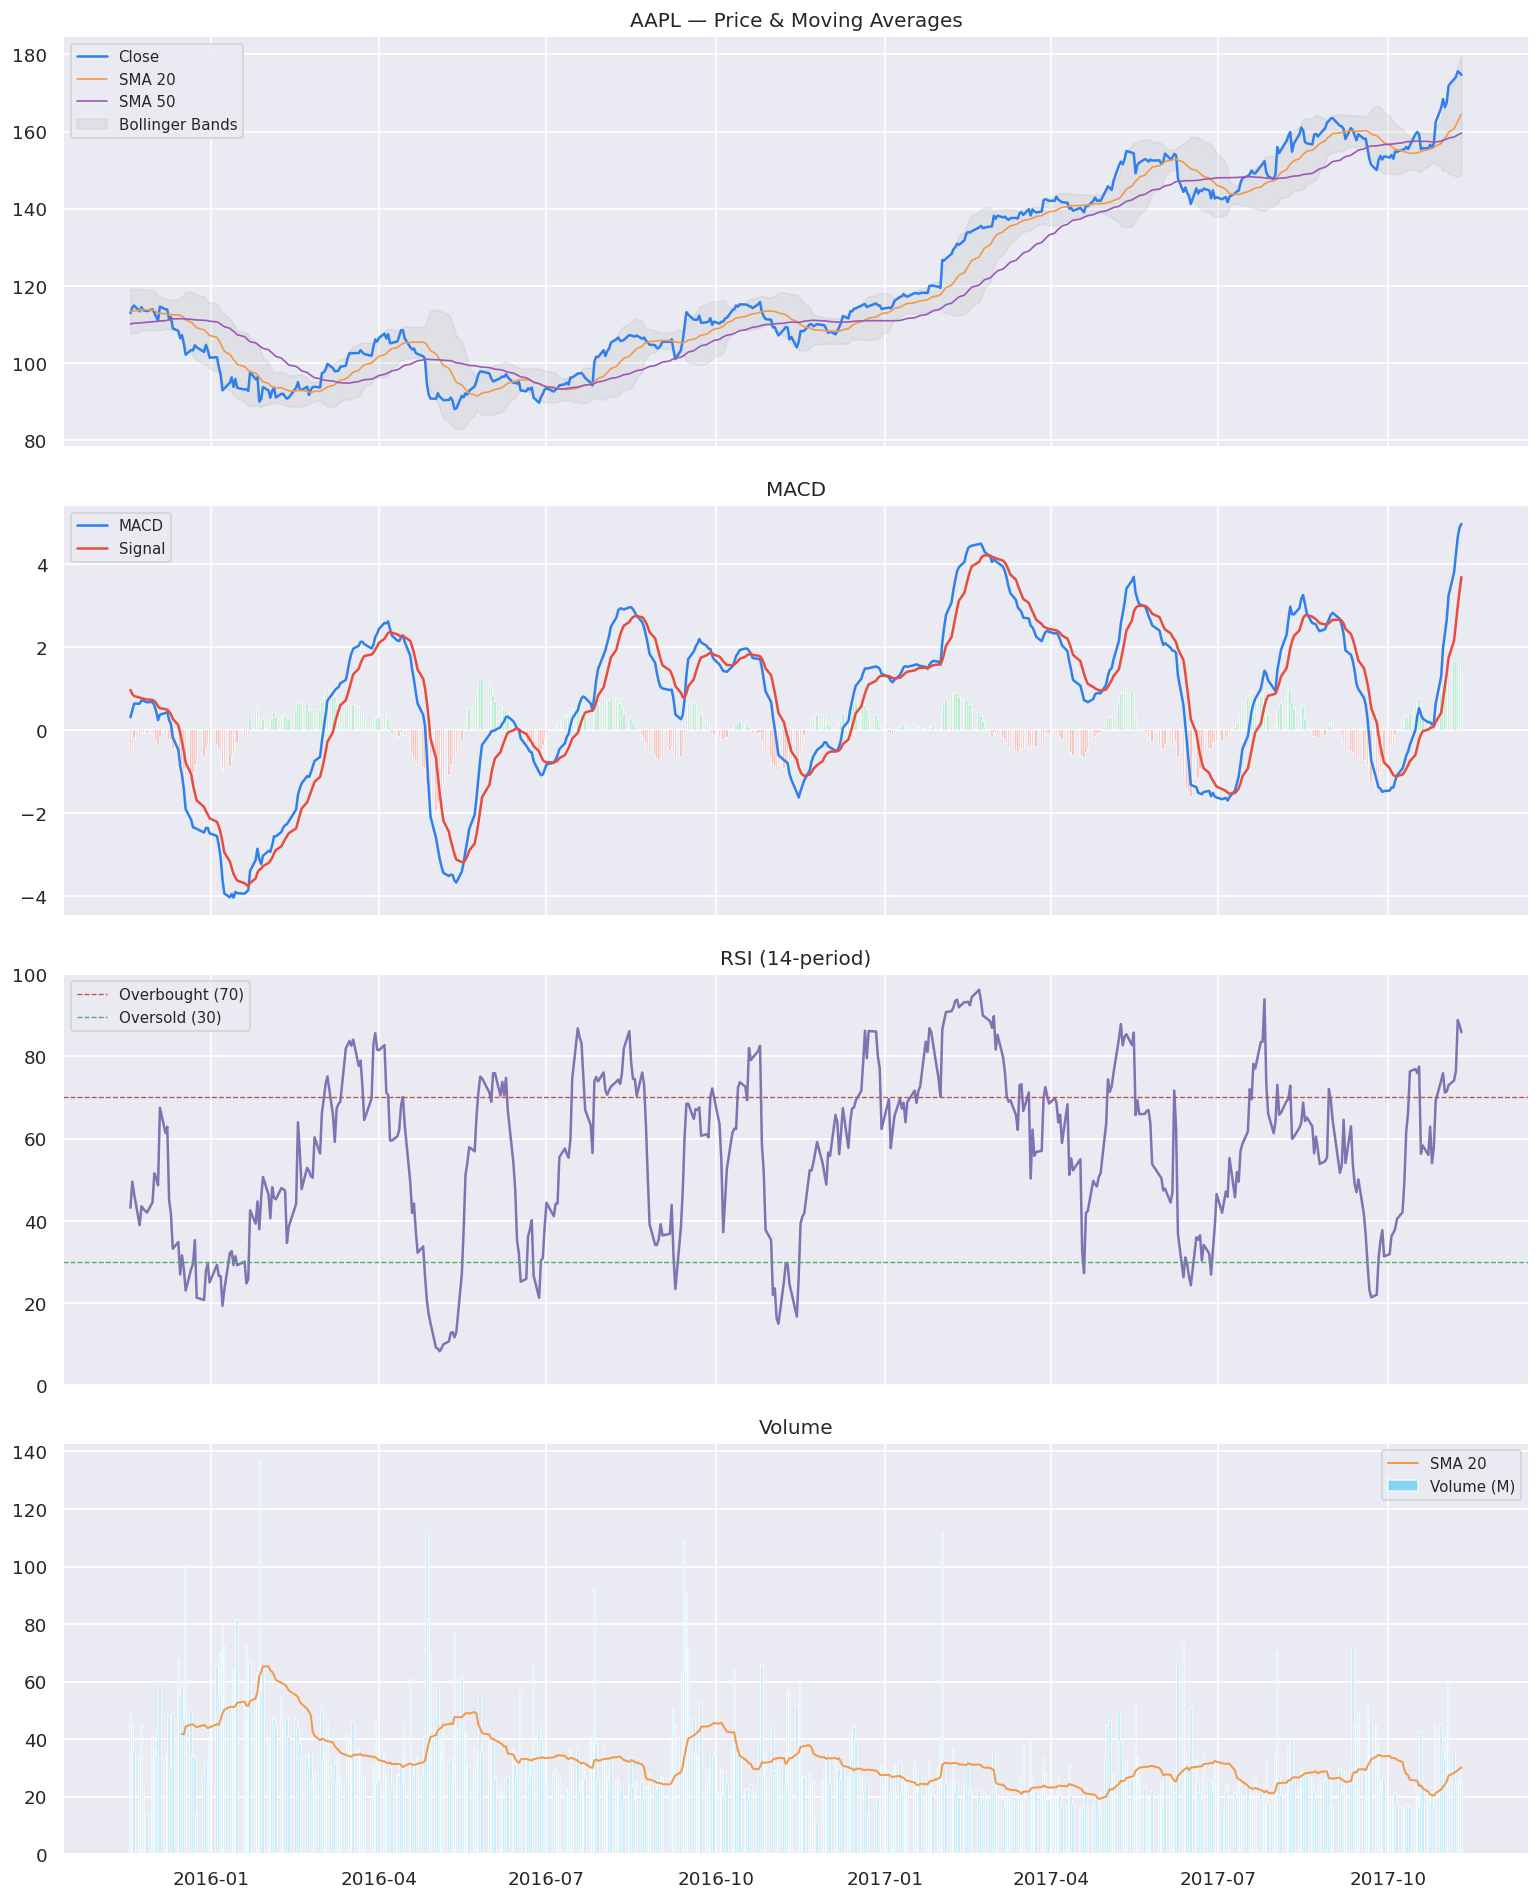

In [10]:
# Plot technical indicators
recent = df.tail(500)
fig, axes = plt.subplots(4, 1, figsize=(13, 16), sharex=True)

axes[0].plot(recent.index, recent['Close'],   color='#2F80ED', label='Close',     linewidth=1.5)
axes[0].plot(recent.index, recent['SMA_20'],  color='#F2994A', label='SMA 20',    linewidth=1)
axes[0].plot(recent.index, recent['SMA_50'],  color='#9B59B6', label='SMA 50',    linewidth=1)
axes[0].fill_between(recent.index, recent['BB_Upper'], recent['BB_Lower'],
                     alpha=0.1, color='gray', label='Bollinger Bands')
axes[0].set_title(f'{TICKER} — Price & Moving Averages', fontsize=12)
axes[0].legend(fontsize=9)

axes[1].plot(recent.index, recent['MACD'],   color='#2F80ED', label='MACD')
axes[1].plot(recent.index, recent['Signal'], color='#E74C3C', label='Signal')
axes[1].bar(recent.index,  recent['MACD_Hist'],
            color=['#2ecc71' if x >= 0 else '#e74c3c' for x in recent['MACD_Hist']], alpha=0.6)
axes[1].set_title('MACD', fontsize=12)
axes[1].legend(fontsize=9)

axes[2].plot(recent.index, recent['RSI'], color='#8172B2', linewidth=1.5)
axes[2].axhline(70, color='r', linestyle='--', linewidth=0.8, label='Overbought (70)')
axes[2].axhline(30, color='g', linestyle='--', linewidth=0.8, label='Oversold (30)')
axes[2].set_ylim(0, 100)
axes[2].set_title('RSI (14-period)', fontsize=12)
axes[2].legend(fontsize=9)

axes[3].bar(recent.index, recent['Volume'] / 1e6, color='#56CCF2', alpha=0.7, label='Volume (M)')
axes[3].plot(recent.index, recent['Volume'].rolling(20).mean() / 1e6,
             color='#F2994A', linewidth=1.2, label='SMA 20')
axes[3].set_title('Volume', fontsize=12)
axes[3].legend(fontsize=9)

plt.tight_layout()
plt.savefig('plots/technical_indicators.png', bbox_inches='tight')
plt.show()

## 4 · Prepare LSTM Sequences

In [11]:
FEATURES = ['Close','SMA_20','SMA_50','MACD','RSI','BB_Width',
            'Return','Volatility','Momentum_5','Vol_Ratio']
SEQ_LEN  = 60   # 60 trading days ≈ 3 months lookback

scaler = MinMaxScaler()
scaled = scaler.fit_transform(df[FEATURES].values)

def make_sequences(arr, seq_len, target_idx=0):
    X, y = [], []
    for i in range(seq_len, len(arr)):
        X.append(arr[i-seq_len:i])
        y.append(arr[i, target_idx])
    return np.array(X), np.array(y)

X_all, y_all = make_sequences(scaled, SEQ_LEN)

n = len(X_all)
train_end = int(n * 0.80)
val_end   = int(n * 0.90)

X_train, y_train = X_all[:train_end],           y_all[:train_end]
X_val,   y_val   = X_all[train_end:val_end],    y_all[train_end:val_end]
X_test,  y_test  = X_all[val_end:],             y_all[val_end:]

print(f'Train : {X_train.shape}')
print(f'Val   : {X_val.shape}')
print(f'Test  : {X_test.shape}')

Train : (6603, 60, 10)
Val   : (825, 60, 10)
Test  : (826, 60, 10)


## 5 · Model Comparison

In [12]:
def inv_close(arr, scaler, n_feat):
    """Inverse-transform scaled Close column back to price."""
    dummy = np.zeros((len(arr), n_feat))
    dummy[:, 0] = arr
    return scaler.inverse_transform(dummy)[:, 0]

def eval_model(true, pred, name=''):
    rmse = np.sqrt(mean_squared_error(true, pred))
    mae  = mean_absolute_error(true, pred)
    mape = np.mean(np.abs((true - pred) / (true + 1e-9))) * 100
    dacc = np.mean(np.sign(np.diff(true)) == np.sign(np.diff(pred))) * 100
    print(f'{name:30s}  RMSE:${rmse:.2f}  MAE:${mae:.2f}  MAPE:{mape:.2f}%  DirAcc:{dacc:.1f}%')
    return dict(RMSE=round(rmse,2), MAE=round(mae,2), MAPE=round(mape,2), DirAcc=round(dacc,1))

results = {}

In [13]:
# ── Baseline: predict last known price (naive) ────────────────────────────────
true_prices  = inv_close(y_test, scaler, len(FEATURES))
naive_pred   = inv_close(X_test[:, -1, 0], scaler, len(FEATURES))
results['Naive (last price)'] = eval_model(true_prices, naive_pred, 'Naive (last price)')

Naive (last price)              RMSE:$1.63  MAE:$1.17  MAPE:1.02%  DirAcc:49.1%


In [14]:
# ── Vanilla LSTM (GPU-accelerated) ───────────────────────────────────────────
def build_lstm(seq_len, n_feat):
    """Vanilla LSTM built inside distribution strategy scope for GPU support."""
    with strategy.scope():
        inp = keras.Input(shape=(seq_len, n_feat))
        x   = layers.LSTM(64, return_sequences=False)(inp)
        x   = layers.Dropout(0.2)(x)
        x   = layers.Dense(16, activation='relu')(x)
        # float32 output layer required when using mixed_float16 policy
        out = layers.Dense(1, dtype='float32')(x)
        m   = keras.Model(inp, out)
        m.compile(
            optimizer=keras.optimizers.Adam(0.001),
            loss='huber',
            metrics=['mae']
        )
    return m

lstm = build_lstm(SEQ_LEN, len(FEATURES))
lstm.summary()

callbacks = [
    keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True, verbose=1),
    keras.callbacks.ReduceLROnPlateau(patience=3, factor=0.5, verbose=1),
    keras.callbacks.TensorBoard(log_dir='logs/lstm', histogram_freq=0) if USE_GPU else
    keras.callbacks.TerminateOnNaN()
]

history_lstm = lstm.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1
)

lstm_pred = inv_close(lstm.predict(X_test, verbose=0).flatten(), scaler, len(FEATURES))
results['Vanilla LSTM'] = eval_model(true_prices, lstm_pred, 'Vanilla LSTM')
print('\nVanilla LSTM done ✓')


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 60, 10)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        19,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,257 (79.13 KB)

 Trainable params: 20,257 (79.13 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - loss: 3.7703e-04 - mae: 0.0169 - val_loss: 0.0013 - val_mae: 0.0427 - learning_rate: 0.0010
Epoch 2/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 4.9126e-05 - mae: 0.0064 - val_loss: 0.0033 - val_mae: 0.0739 - learning_rate: 0.0010
Epoch 3/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 4.0954e-05 - mae: 0.0057 - val_loss: 0.0031 - val_mae: 0.0706 - learning_rate: 0.0010
Epoch 4/50
 99/104 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 3.5881e-05 - mae: 0.0054
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 3.3982e-05 - mae: 0.0053 - val_loss: 0.0025 - val_mae: 0.0635 - learning_rate: 0.0010
Epoch 5/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 2.8864e-05 - mae: 0.0049 - val_loss: 0.0021 - val_mae: 0.0567 - learning_rate: 5.0000e-04
Epoch 6/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 2.5548e-05 - mae: 0.0047 - val_loss: 0.0021 - val

In [15]:
# ── Bidirectional LSTM (GPU-accelerated + Mixed Precision) ───────────────────
def build_bilstm(seq_len, n_feat):
    """
    Bidirectional LSTM with:
    - Mixed precision (float16) for 2-3× GPU speedup
    - MirroredStrategy for multi-GPU support
    - Batch Normalization for stable training
    - L2 regularization to prevent overfitting
    """
    with strategy.scope():
        reg = keras.regularizers.l2(1e-4)
        inp = keras.Input(shape=(seq_len, n_feat))

        # BiLSTM layer 1 — 64 units each direction → 128 total
        x = layers.Bidirectional(
            layers.LSTM(64, return_sequences=True, kernel_regularizer=reg)
        )(inp)
        x = layers.BatchNormalization()(x)
        x = layers.Dropout(0.2)(x)

        # BiLSTM layer 2 — 32 units each direction → 64 total
        x = layers.Bidirectional(
            layers.LSTM(32, return_sequences=False, kernel_regularizer=reg)
        )(x)
        x = layers.BatchNormalization()(x)
        x = layers.Dropout(0.2)(x)

        # Dense head
        x   = layers.Dense(32, activation='relu', kernel_regularizer=reg)(x)
        x   = layers.Dropout(0.1)(x)
        x   = layers.Dense(16, activation='relu')(x)
        # Must be float32 output when using mixed_float16 policy
        out = layers.Dense(1, dtype='float32')(x)

        m = keras.Model(inp, out, name='BiLSTM_StockPredictor')
        m.compile(
            optimizer=keras.optimizers.Adam(learning_rate=0.001),
            loss='huber',
            metrics=['mae']
        )
    return m

bilstm = build_bilstm(SEQ_LEN, len(FEATURES))
bilstm.summary()
print(f'\nTotal parameters: {bilstm.count_params():,}')
print(f'Training on: {"GPU (mixed float16)" if USE_GPU else "CPU (float32)"}')

callbacks_bi = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=7,
        restore_best_weights=True, verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', patience=4,
        factor=0.4, min_lr=1e-6, verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        'models/bilstm_best.keras',
        monitor='val_loss', save_best_only=True, verbose=0
    ),
]

history_bi = bilstm.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,               # More epochs — EarlyStopping handles cutoff
    batch_size=BATCH_SIZE,    # 64 on GPU, 32 on CPU
    callbacks=callbacks_bi,
    verbose=1
)

bilstm_pred = inv_close(bilstm.predict(X_test, verbose=0).flatten(), scaler, len(FEATURES))
results['Bidirectional LSTM'] = eval_model(true_prices, bilstm_pred, 'Bidirectional LSTM')
print('\nBidirectional LSTM done ✓')
print('\nAll Results:')
for name, metrics in results.items():
    print(f"  {name:25s}  RMSE={metrics['RMSE']:.2f}  MAPE={metrics['MAPE']:.2f}%  DirAcc={metrics['DirAcc']:.1f}%")


Model: "BiLSTM_StockPredictor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 60, 10)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 60, 128)        │        38,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 60, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 60, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 83,009 (324.25 KB)

 Trainable params: 82,625 (322.75 KB)

 Non-trainable params: 384 (1.50 KB)


Total parameters: 83,009
Training on: GPU (mixed float16)
Epoch 1/100
104/104 ━━━━━━━━━━━━━━━━━━━━ 7s 34ms/step - loss: 0.1452 - mae: 0.3436 - val_loss: 0.0901 - val_mae: 0.3314 - learning_rate: 0.0010
Epoch 2/100
104/104 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - loss: 0.0520 - mae: 0.1476 - val_loss: 0.0878 - val_mae: 0.3248 - learning_rate: 0.0010
Epoch 3/100
104/104 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - loss: 0.0415 - mae: 0.1036 - val_loss: 0.0965 - val_mae: 0.3515 - learning_rate: 0.0010
Epoch 4/100
104/104 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - loss: 0.0366 - mae: 0.0816 - val_loss: 0.0870 - val_mae: 0.3280 - learning_rate: 0.0010
Epoch 5/100
104/104 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - loss: 0.0334 - mae: 0.0653 - val_loss: 0.0596 - val_mae: 0.2404 - learning_rate: 0.0010
Epoch 6/100
104/104 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - loss: 0.0310 - mae: 0.0542 - val_loss: 0.0709 - val_mae: 0.2837 - learning_rate: 0.0010
Epoch 7/100
104/104 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - loss: 0.0290 - mae: 0

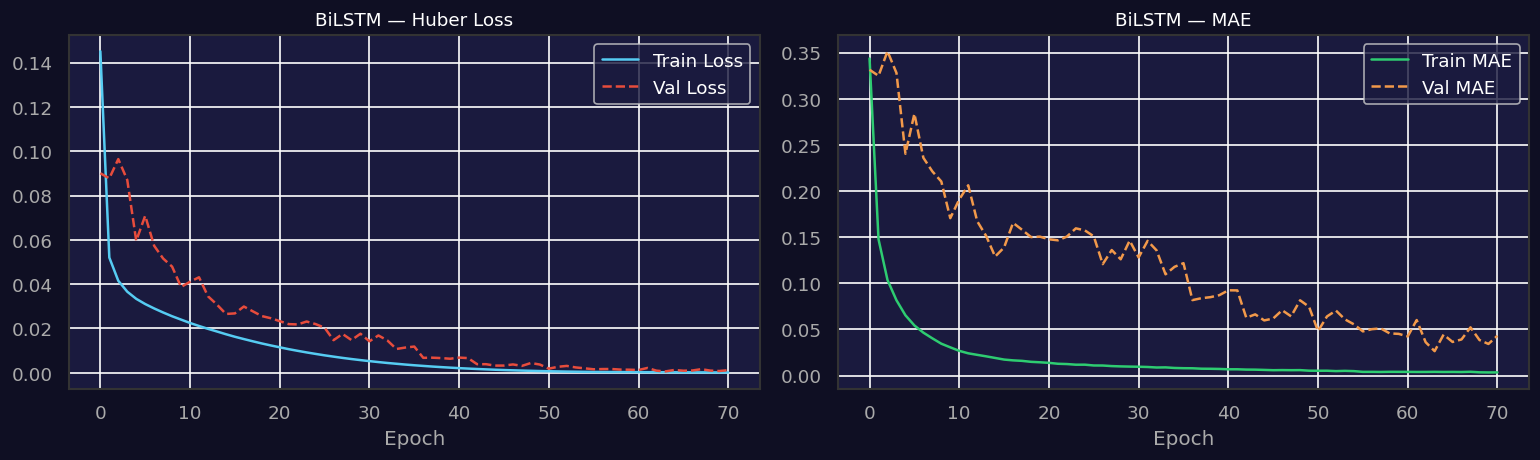

Training history saved ✓


In [16]:
# ── Plot training history (loss + MAE curves) ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4), facecolor='#0f0f23')
for ax in axes:
    ax.set_facecolor('#1a1a3e')
    ax.tick_params(colors='#aaa')
    for spine in ax.spines.values():
        spine.set_color('#333')

# Loss
axes[0].plot(history_bi.history['loss'],     color='#56CCF2', label='Train Loss')
axes[0].plot(history_bi.history['val_loss'], color='#E74C3C', label='Val Loss',  linestyle='--')
axes[0].set_title('BiLSTM — Huber Loss', color='white', fontsize=11)
axes[0].set_xlabel('Epoch', color='#aaa')
axes[0].legend(labelcolor='white', facecolor='#1a1a3e')

# MAE
axes[1].plot(history_bi.history['mae'],     color='#2ecc71', label='Train MAE')
axes[1].plot(history_bi.history['val_mae'], color='#F2994A', label='Val MAE',   linestyle='--')
axes[1].set_title('BiLSTM — MAE', color='white', fontsize=11)
axes[1].set_xlabel('Epoch', color='#aaa')
axes[1].legend(labelcolor='white', facecolor='#1a1a3e')

plt.tight_layout()
plt.savefig('plots/training_history.png', bbox_inches='tight',
            facecolor='#0f0f23', dpi=150)
plt.show()
print('Training history saved ✓')


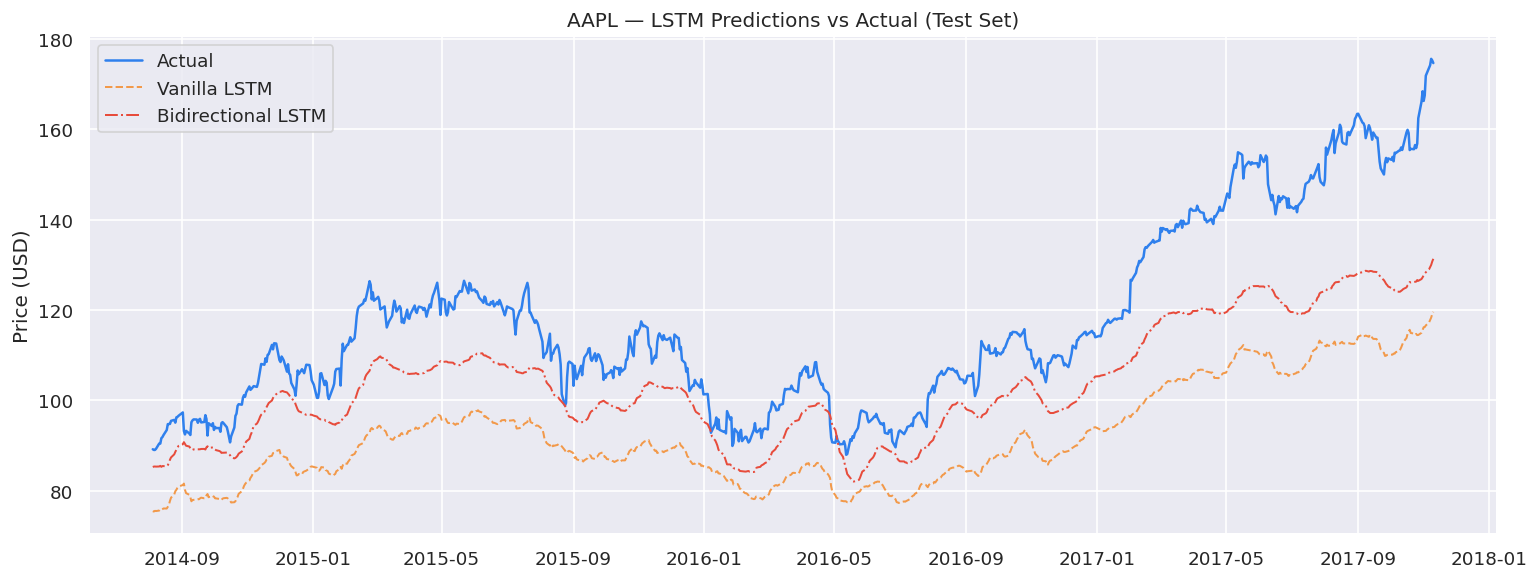

In [17]:
# ── Plot predictions vs actual ────────────────────────────────────────────────
test_dates = df.index[-len(true_prices):]

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(test_dates, true_prices,  label='Actual',              color='#2F80ED', linewidth=1.5)
ax.plot(test_dates, lstm_pred,    label='Vanilla LSTM',        color='#F2994A', linewidth=1.2, linestyle='--')
ax.plot(test_dates, bilstm_pred,  label='Bidirectional LSTM',  color='#E74C3C', linewidth=1.2, linestyle='-.')
ax.set_title(f'{TICKER} — LSTM Predictions vs Actual (Test Set)', fontsize=12)
ax.set_ylabel('Price (USD)')
ax.legend()
plt.tight_layout()
plt.savefig('plots/predictions_vs_actual.png', bbox_inches='tight')
plt.show()

## 6 · 30-Day Forecast

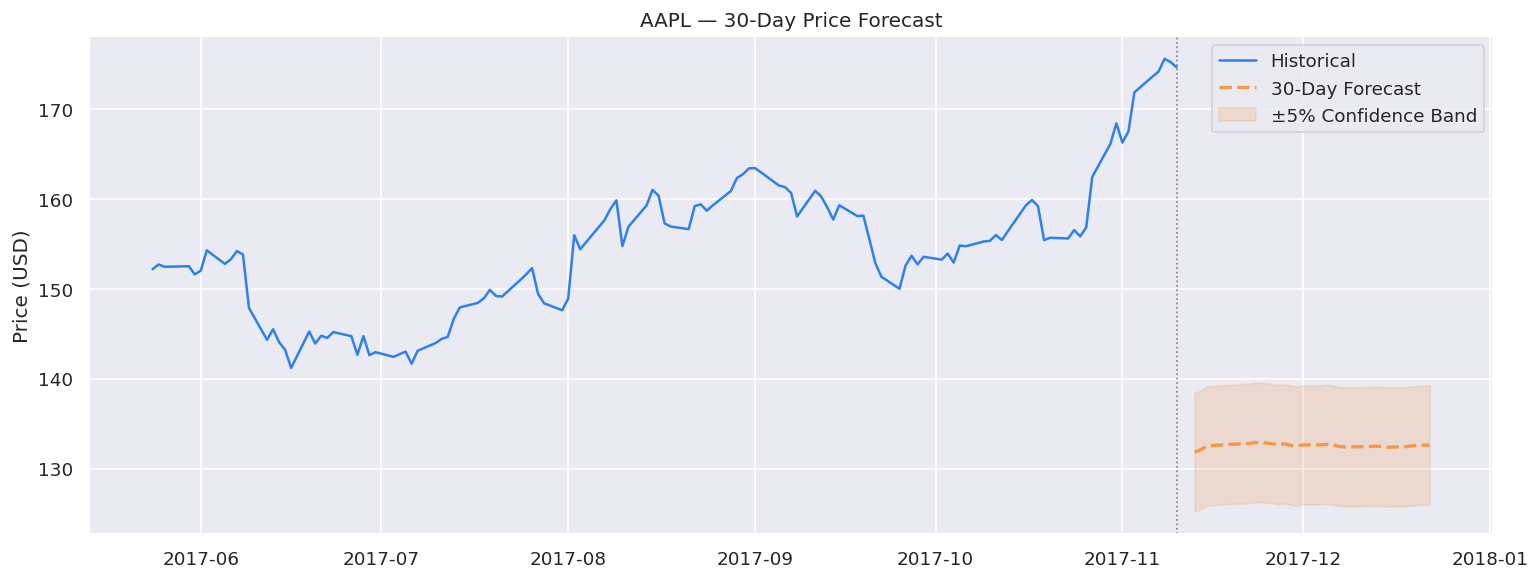

In [18]:
def forecast_n_days(model, scaled_data, scaler, n_feat, n_days=30, seq_len=60):
    last_seq = scaled_data[-seq_len:].copy()
    preds = []
    for _ in range(n_days):
        x_in = last_seq.reshape(1, seq_len, n_feat)
        p    = model.predict(x_in, verbose=0)[0, 0]
        preds.append(p)
        new_row = last_seq[-1].copy()
        new_row[0] = p
        last_seq = np.vstack([last_seq[1:], [new_row]])
    dummy = np.zeros((len(preds), n_feat))
    dummy[:, 0] = preds
    return scaler.inverse_transform(dummy)[:, 0]

future_prices = forecast_n_days(bilstm, scaled, scaler, len(FEATURES), n_days=30)
future_dates  = pd.date_range(df.index[-1] + pd.Timedelta(days=1), periods=30, freq='B')

fig, ax = plt.subplots(figsize=(13, 5))
hist_slice = df['Close'].iloc[-120:]
ax.plot(hist_slice.index, hist_slice.values,  color='#2F80ED',  label='Historical', linewidth=1.5)
ax.plot(future_dates,     future_prices,       color='#F2994A',  label='30-Day Forecast', linewidth=2, linestyle='--')
ax.fill_between(future_dates, future_prices*0.95, future_prices*1.05,
                alpha=0.2, color='#F2994A', label='±5% Confidence Band')
ax.axvline(df.index[-1], color='gray', linestyle=':', linewidth=1)
ax.set_title(f'{TICKER} — 30-Day Price Forecast', fontsize=12)
ax.set_ylabel('Price (USD)')
ax.legend()
plt.tight_layout()
plt.savefig('plots/forecast_30days.png', bbox_inches='tight')
plt.show()

## 7 · Save Model & Artifacts

In [19]:
bilstm.save('models/lstm_model.keras')
with open('models/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

meta = {
    'ticker': TICKER,
    'features': FEATURES,
    'seq_len': SEQ_LEN,
    'model': 'Bidirectional LSTM',
    'model_comparison': results,
    'test_rmse': results['Bidirectional LSTM']['RMSE'],
    'test_mae':  results['Bidirectional LSTM']['MAE'],
    'test_mape': results['Bidirectional LSTM']['MAPE'],
    'direction_accuracy': results['Bidirectional LSTM']['DirAcc'],
    'forecast_30d': [round(float(p), 4) for p in future_prices],
    'forecast_dates': [str(d.date()) for d in future_dates]
}
with open('models/metadata.json', 'w') as f:
    json.dump(meta, f, indent=2)

print('Model and metadata saved.')
print(json.dumps({k:v for k,v in meta.items() if 'forecast' not in k}, indent=2))

Model and metadata saved.
{
  "ticker": "AAPL",
  "features": [
    "Close",
    "SMA_20",
    "SMA_50",
    "MACD",
    "RSI",
    "BB_Width",
    "Return",
    "Volatility",
    "Momentum_5",
    "Vol_Ratio"
  ],
  "seq_len": 60,
  "model": "Bidirectional LSTM",
  "model_comparison": {
    "Naive (last price)": {
      "RMSE": 1.63,
      "MAE": 1.17,
      "MAPE": 1.02,
      "DirAcc": 49.1
    },
    "Vanilla LSTM": {
      "RMSE": 26.99,
      "MAE": 25.15,
      "MAPE": 20.75,
      "DirAcc": 50.3
    },
    "Bidirectional LSTM": {
      "RMSE": 15.99,
      "MAE": 13.54,
      "MAPE": 10.81,
      "DirAcc": 52.0
    }
  },
  "test_rmse": 15.99,
  "test_mae": 13.54,
  "test_mape": 10.81,
  "direction_accuracy": 52.0
}
